In [1]:
# ==========================================
# 1. IMPORTACIONES NECESARIAS
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [2]:
!pip install keras-tuner


   ---------------------------------------- 2/2 [keras-tuner]




[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 5.5/5.5 MB 56.0 MB/s  0:00:00

   -------------------- ------------------- 2/4 [markdown]
   ------------------------------ --------- 3/4 [tensorboard]
   ------------------------------ --------- 3/4 [tensorboard]
   ------------------------------ --------- 3/4 [tensorboard]
   ---------------------------------------- 4/4 [tensorboard]




[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================================
# 2. LECTURA Y PREPROCESADO DE DATOS (HOME CREDIT)
# ==========================================

print("Cargando datos...")
df = pd.read_csv('application_train.csv')

df

Cargando datos...


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(df.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("--- INICIANDO PREPROCESADO ROBUSTO ---")

# 1. Cargar datos
df = pd.read_csv('application_train.csv')

# 2. Limpieza estricta inicial
# Nos quedamos solo con M y F (tiramos los raros 'XNA' que puedan causar NaNs)
df = df[df['CODE_GENDER'].isin(['M', 'F'])].copy()
# Mapeamos a binario (0 y 1)
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})

# Tiramos cualquier fila que misteriosamente no tenga Target o Género
df = df.dropna(subset=['TARGET', 'CODE_GENDER'])

# 3. Definir variables
columnas_num = ['AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] # METER LAS COLUMNAS QUE FALTAN
var_sensible = 'CODE_GENDER'
var_objetivo = 'TARGET'

X = df[columnas_num + [var_sensible]]
Y = df[var_objetivo].values.reshape(-1, 1)

# 4. Pipeline de transformación
# A los datos numéricos (índices 0 al 4): Rellenamos NaNs con la media y Escalamos
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, [0, 1, 2, 3, 4]),
        ('passthrough', 'passthrough', [5]) # El género (índice 5) pasa tal cual (0 y 1)
    ]
)

# Aplicamos la transformación a toda la X
X_processed = preprocessor.fit_transform(X)

# --- VERIFICACIÓN DE SEGURIDAD ---
print("¿Quedan NaNs en X_processed?:", np.isnan(X_processed).any()) 

# 5. División de datos (80% Train, 10% Val, 10% Test)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_processed, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# 6. Extraer la variable sensible para la auditoría y la Loss FAIR
S_train = X_train[:, 5]
S_val = X_val[:, 5]
S_test = X_test[:, 5]

print("--- PREPROCESADO COMPLETADO ---")
print(f"Train: {X_train.shape[0]} filas | Val: {X_val.shape[0]} filas | Test: {X_test.shape[0]} filas")

--- INICIANDO PREPROCESADO ROBUSTO ---
¿Quedan NaNs en X_processed?: False
--- PREPROCESADO COMPLETADO ---
Train: 246005 filas | Val: 30751 filas | Test: 30751 filas


In [5]:
# 1. Comprobar si hay NaNs
print("¿Hay NaNs en X_train?:", np.isnan(X_train).any())
print("¿Hay NaNs en Y_train?:", np.isnan(Y_train).any())

# 2. PARCHE DE SEGURIDAD: Si hay NaNs, los rellenamos temporalmente con 0
# (Lo ideal sería volver a correr el preprocesado desde cero, pero esto lo arregla rápido)
X_train = np.nan_to_num(X_train, nan=0.0)
X_val = np.nan_to_num(X_val, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)
Y_train = np.nan_to_num(Y_train, nan=0.0)
Y_val = np.nan_to_num(Y_val, nan=0.0)

# 3. Comprobar que los datos están escalados (La media debería estar cerca de 0)
print("Media de la primera columna (debe ser cercana a 0):", np.mean(X_train[:, 0]))

¿Hay NaNs en X_train?: False
¿Hay NaNs en Y_train?: False
Media de la primera columna (debe ser cercana a 0): -0.0007578512609436168


--- ENTRENANDO MODELO BASE (SIN RESTRICCIONES FAIR) ---


c:\Users\eneko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 3s 761us/step - accuracy: 0.8672 - loss: 0.3696 - val_accuracy: 0.9169 - val_loss: 0.2663
Epoch 2/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 3s 744us/step - accuracy: 0.9194 - loss: 0.2576 - val_accuracy: 0.9168 - val_loss: 0.2614
Epoch 3/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9193 - loss: 0.2555 - val_accuracy: 0.9170 - val_loss: 0.2613
Epoch 4/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 3s 808us/step - accuracy: 0.9194 - loss: 0.2554 - val_accuracy: 0.9170 - val_loss: 0.2613
Epoch 5/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9194 - loss: 0.2554 - val_accuracy: 0.9168 - val_loss: 0.2613
Epoch 6/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9194 - loss: 0.2554 - val_accuracy: 0.9170 - val_loss: 0.2612
Epoch 7/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9194 - loss: 0.2554 - val_accuracy: 0.9172 - val_loss: 0.2613
Epoch 8/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 3s 740us/step - accuracy: 0.9194 - loss: 0

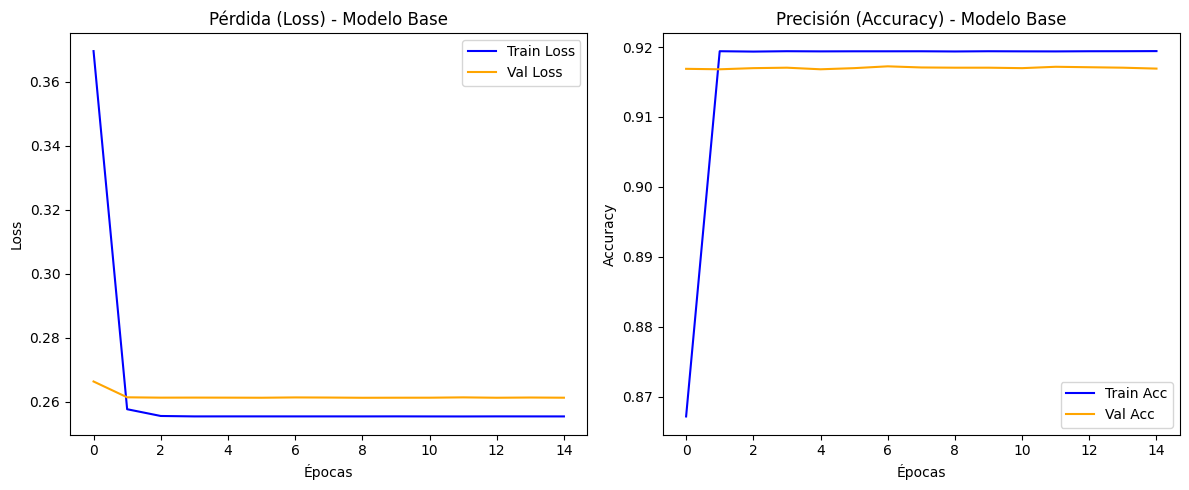


--- EVALUACIÓN DE SESGO EN EL MODELO BASE ---
961/961 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step
Correlación de Pearson (Predicción vs Género): -0.2175
Accuracy en conjunto de Test: 0.9194


In [6]:
import matplotlib.pyplot as plt
import scipy.stats

print("--- ENTRENANDO MODELO BASE (SIN RESTRICCIONES FAIR) ---")

# 1. Definir una red neuronal densa simple
model_base = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    #keras.layers.Dropout(0.0),
    keras.layers.Dense(1, activation='sigmoid')
])

#optimizador_custom = keras.optimizers.Adam(learning_rate=0.001)

# Usamos la pérdida estándar (Binary Crossentropy), sin penalizar sesgos
model_base.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

model_base.summary()

# 2. Entrenar el modelo (usamos Y_train normal, no Y_train_ext)
hist_base = model_base.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

# 3. Dibujar las curvas de aprendizaje (Loss y Accuracy)
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(hist_base.history['loss'], label='Train Loss', color='blue')
plt.plot(hist_base.history['val_loss'], label='Val Loss', color='orange')
plt.title('Pérdida (Loss) - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist_base.history['accuracy'], label='Train Acc', color='blue')
plt.plot(hist_base.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Precisión (Accuracy) - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Auditoría rápida de Fairness en el modelo Base
print("\n--- EVALUACIÓN DE SESGO EN EL MODELO BASE ---")
y_pred_base = model_base.predict(X_test).flatten()

# Medimos la correlación entre la predicción y el género (S_test)
pearson_corr_base, _ = scipy.stats.pearsonr(y_pred_base, S_test)
print(f"Correlación de Pearson (Predicción vs Género): {pearson_corr_base:.4f}")

# Guardamos la métrica de accuracy en test para tu tabla final
loss_test, acc_test = model_base.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy en conjunto de Test: {acc_test:.4f}")

--- CREANDO CAPA CUSTOMIZADA ---
Capa 'CapaRatioEndeudamiento' registrada correctamente.

--- ENTRENANDO MODELO 2 (CON CAPA CUSTOM) ---



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_ratio_endeudamiento        │ (None, 7)              │             0 │
│ (CapaRatioEndeudamiento)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 965us/step - accuracy: 0.9177 - loss: 0.2753 - val_accuracy: 0.9170 - val_loss: 0.2614
Epoch 2/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 905us/step - accuracy: 0.9195 - loss: 0.2610 - val_accuracy: 0.9170 - val_loss: 0.2610
Epoch 3/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 915us/step - accuracy: 0.9195 - loss: 0.2591 - val_accuracy: 0.9170 - val_loss: 0.2606
Epoch 4/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 955us/step - accuracy: 0.9195 - loss: 0.2580 - val_accuracy: 0.9170 - val_loss: 0.2608
Epoch 5/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 955us/step - accuracy: 0.9195 - loss: 0.2574 - val_accuracy: 0.9170 - val_loss: 0.2603
Epoch 6/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 957us/step - accuracy: 0.9195 - loss: 0.2568 - val_accuracy: 0.9170 - val_loss: 0.2602
Epoch 7/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 936us/step - accuracy: 0.9195 - loss: 0.2566 - val_accuracy: 0.9170 - val_loss: 0.2602
Epoch 8/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 938us/step - accuracy: 0.9195 -

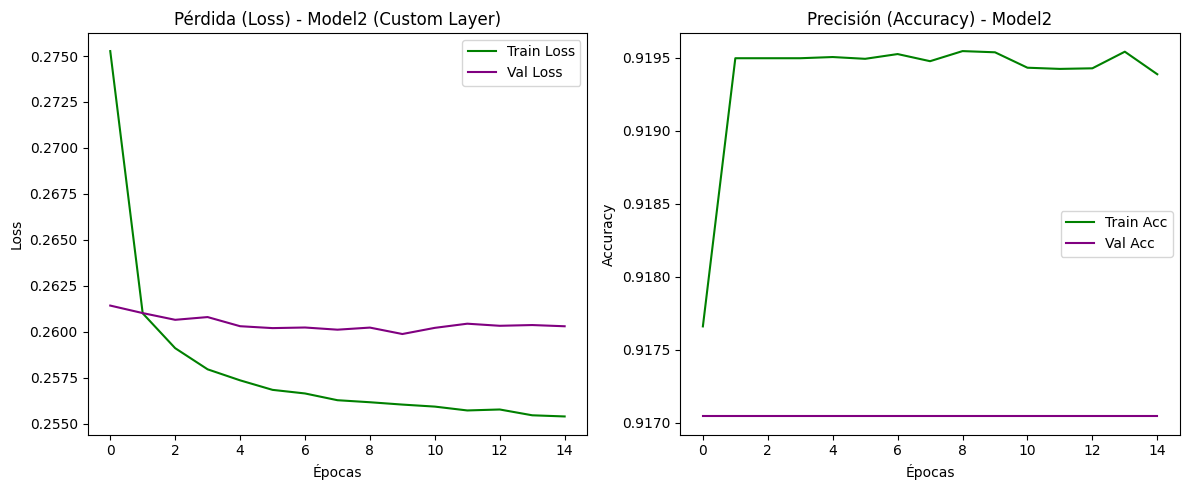


--- EVALUACIÓN DE SESGO EN EL MODELO 2 ---
961/961 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step
Accuracy en Test (Model2): 0.9197
Correlación de Pearson (Predicción vs Género): -0.2365


In [7]:
# ==========================================
# 4. CLASES CUSTOMIZADAS (CAPA Y LOSS)
# ==========================================
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import scipy.stats

print("--- CREANDO CAPA CUSTOMIZADA ---")

# 1. Definición de la Capa Customizada
class CapaRatioEndeudamiento(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Según nuestro preprocesado:
        # Índice 0 -> AMT_INCOME_TOTAL
        # Índice 1 -> AMT_ANNUITY
        ingresos = inputs[:, 0:1]
        anualidad = inputs[:, 1:2]
        
        # Calculamos el ratio (añadimos epsilon para evitar división por 0)
        ratio = anualidad / (ingresos + keras.backend.epsilon())
        
        # Aplicamos la restricción matemática (saturación)
        ratio_saturado = keras.ops.tanh(ratio)
        
        # Devolvemos las entradas originales pegadas a nuestra nueva característica
        return keras.ops.concatenate([inputs, ratio_saturado], axis=-1)

    def get_config(self):
        return super().get_config()

print("Capa 'CapaRatioEndeudamiento' registrada correctamente.")

# 2. Construcción del model2
print("\n--- ENTRENANDO MODELO 2 (CON CAPA CUSTOM) ---")

model2 = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    
    # ¡Nuestra nueva capa física/matemática!
    CapaRatioEndeudamiento(),
    
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

# Usamos el mismo optimizador seguro que antes
optimizador_m2 = keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

model2.compile(optimizer=optimizador_m2,
               loss='binary_crossentropy',
               metrics=['accuracy'])

model2.summary()

# 3. Entrenamiento
hist2 = model2.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

# 4. Gráficas de convergencia del model2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist2.history['loss'], label='Train Loss', color='green')
plt.plot(hist2.history['val_loss'], label='Val Loss', color='purple')
plt.title('Pérdida (Loss) - Model2 (Custom Layer)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist2.history['accuracy'], label='Train Acc', color='green')
plt.plot(hist2.history['val_accuracy'], label='Val Acc', color='purple')
plt.title('Precisión (Accuracy) - Model2')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 5. Evaluación del model2
print("\n--- EVALUACIÓN DE SESGO EN EL MODELO 2 ---")
y_pred_m2 = model2.predict(X_test).flatten()

pearson_corr_m2, _ = scipy.stats.pearsonr(y_pred_m2, S_test)
loss_test_m2, acc_test_m2 = model2.evaluate(X_test, Y_test, verbose=0)

print(f"Accuracy en Test (Model2): {acc_test_m2:.4f}")
print(f"Correlación de Pearson (Predicción vs Género): {pearson_corr_m2:.4f}")

In [9]:
import keras
import numpy as np

class CustomFairnessLoss(keras.losses.Loss):
    def __init__(self, lambda_correlation=0.1, name="custom_fairness_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_correlation = lambda_correlation
        # Usamos BinaryCrossentropy para la parte principal de la pérdida, adecuada para clasificación binaria
        self.bce = keras.losses.BinaryCrossentropy(from_logits=False) # Asumiendo que y_pred_single son probabilidades

    def call(self, y_true_extended, y_pred_single):
        # y_true_extended se espera que sea un tensor con dos columnas: [y_true_real, variable_sensible]
        # y_pred_single es la predicción del modelo (e.g., probabilidad única)

        y_true_actual = y_true_extended[:, 0]
        s_true = y_true_extended[:, 1]

        # Asegurarse de que y_pred_single y s_true sean tensores de una sola columna si vienen con una dimensión extra
        y_pred_single = keras.ops.squeeze(y_pred_single, axis=-1) if y_pred_single.ndim > 1 else y_pred_single
        s_true = keras.ops.squeeze(s_true, axis=-1) if s_true.ndim > 1 else s_true

        # 1. Calcular la pérdida de Entropía Cruzada Binaria (BCE)
        bce_loss = self.bce(y_true_actual, y_pred_single)

        # 2. Calcular la correlación de Pearson (para la penalización)
        # Se añaden epsilons para prevenir divisiones por cero en caso de desviación estándar cero en el lote
        y_pred_mean = keras.ops.mean(y_pred_single)
        s_true_mean = keras.ops.mean(s_true)

        y_pred_centered = y_pred_single - y_pred_mean
        s_true_centered = s_true - s_true_mean

        covariance = keras.ops.mean(y_pred_centered * s_true_centered)

        y_pred_std = keras.ops.std(y_pred_single)
        s_true_std = keras.ops.std(s_true)

        # Corrected: Use keras.backend.epsilon() for numerical stability
        denominator = (y_pred_std * s_true_std) + keras.backend.epsilon() # Epsilon para estabilidad numérica

        correlation = covariance / denominator

        # Penalizar el cuadrado de la correlación para que tienda a cero
        correlation_penalty = keras.ops.square(correlation)

        # Combinar las pérdidas: BCE principal + penalización de correlación
        total_loss = bce_loss + self.lambda_correlation * correlation_penalty
        return total_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "lambda_correlation": self.lambda_correlation,
        })
        return config

print("Función de coste 'CustomFairnessLoss' creada con éxito usando BinaryCrossentropy y penalización de correlación.")

Función de coste 'CustomFairnessLoss' creada con éxito usando BinaryCrossentropy y penalización de correlación.


In [10]:
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
from tensorflow import keras

print("--- ENTRENANDO MODELO FAIR (CON RESTRICCIÓN DE SESGO) ---")

# 1. Asegurarnos de que tenemos las "Y" extendidas listas (Target + Género)
# Si ya las creaste en el preprocesado, esto solo las reescribe por seguridad
Y_train_ext = np.column_stack((Y_train, S_train))
Y_val_ext = np.column_stack((Y_val, S_val))

# 2. Instanciar la función de coste del profesor
# lambda_correlation controla cuánto nos importa la justicia frente a la precisión.
# Ponemos 0.8 para forzar al modelo a ser justo.
loss_justa = CustomFairnessLoss(lambda_correlation=0.8)   # PROBAR CON VAROIOS, EJEMPPLO DESDE 0.1 hasta 1

# 3. Definir la misma arquitectura que el model2
model_fair = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    CapaRatioEndeudamiento(), # Usamos la capa que creaste antes
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizador_fair = keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

model_fair.compile(optimizer=optimizador_fair,
                   loss=loss_justa, # <--- AQUÍ ESTÁ LA MAGIA
                   metrics=['accuracy'])

# 4. Entrenar el modelo (¡Ojo! Le pasamos Y_train_ext)
hist_fair = model_fair.fit(
    X_train, Y_train_ext,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val_ext),
    verbose=1
)

# 5. Evaluar y comparar resultados
y_pred_fair = model_fair.predict(X_test).flatten()
pearson_corr_fair, _ = scipy.stats.pearsonr(y_pred_fair, S_test)

# Para evaluar la accuracy en test, no podemos usar la evaluate con Y_ext y la loss custom
# porque distorsiona el número. Lo hacemos "a mano":
predicciones_binarias = (y_pred_fair > 0.5).astype(int)
acc_test_fair = np.mean(predicciones_binarias == Y_test.flatten())
print("\n" + "="*50)
print("🏆 COMPARATIVA: MODELO BASE vs MODELO FAIR 🏆")
print("="*50)
print(f"{'Métrica':<25} | {'Model 2 (Sin FAIR)':<20} | {'Model FAIR':<20}")
print("-" * 70)
print(f"{'Accuracy en Test':<25} | {acc_test_m2:.4f}{'':<14} | {acc_test_fair:.4f}")
print(f"{'Correlación (Sesgo)':<25} | {pearson_corr_m2:.4f}{'':<14} | {pearson_corr_fair:.4f}")
print("="*50)

--- ENTRENANDO MODELO FAIR (CON RESTRICCIÓN DE SESGO) ---
Epoch 1/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6270 - loss: 0.3047 - val_accuracy: 0.6299 - val_loss: 0.2757
Epoch 2/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 995us/step - accuracy: 0.6307 - loss: 0.2767 - val_accuracy: 0.6299 - val_loss: 0.2738
Epoch 3/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 991us/step - accuracy: 0.6307 - loss: 0.2730 - val_accuracy: 0.6299 - val_loss: 0.2739
Epoch 4/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 956us/step - accuracy: 0.6307 - loss: 0.2713 - val_accuracy: 0.6299 - val_loss: 0.2734
Epoch 5/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 960us/step - accuracy: 0.6307 - loss: 0.2700 - val_accuracy: 0.6299 - val_loss: 0.2733
Epoch 6/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 988us/step - accuracy: 0.6308 - loss: 0.2695 - val_accuracy: 0.6299 - val_loss: 0.2733
Epoch 7/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 4s 983us/step - accuracy: 0.6308 - loss: 0.2691 - val_accuracy: 0.6299 - val_loss: 0.2729
Epoch 8/15
3844/3844

--- ANÁLISIS DE SENSIBILIDAD: lambda_correlation ---

Entrenando con lambda=0.0... 

c:\Users\eneko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7356  Correlación=-0.2204
Entrenando con lambda=0.1... 

c:\Users\eneko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7316  Correlación=-0.0615
Entrenando con lambda=0.3... 

...

AUC=0.7280  Correlación=-0.0213
Entrenando con lambda=0.8... 

c:\Users\eneko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7245  Correlación=0.0100
Entrenando con lambda=1.0... 

c:\Users\eneko\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7221  Correlación=-0.0070

Lambda     | AUC          | Correlación (Sesgo) 
------------------------------------------------------------
0.7356       | -0.2204             
0.7316       | -0.0615             
0.7292       | -0.0128             
0.7280       | -0.0213             
0.7245       | 0.0100              
0.7221       | -0.0070             


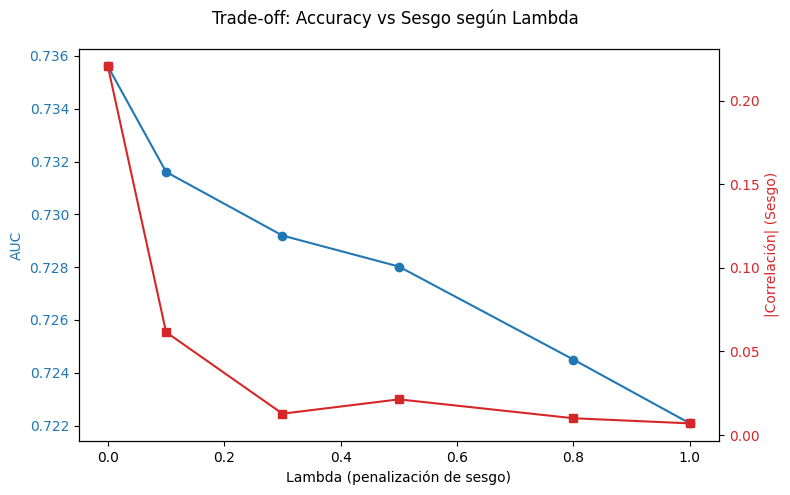


Nota: lambda=0.0 equivale a no penalizar el sesgo (solo BCE).


In [14]:
# ==========================================
# 4B. ANÁLISIS DE SENSIBILIDAD DE LAMBDA
# ==========================================
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
from tensorflow import keras
from sklearn.metrics import roc_auc_score

print("--- ANÁLISIS DE SENSIBILIDAD: lambda_correlation ---\n")

sa_lambdas = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
sa_resultados = []  # lista de diccionarios con los resultados

for lam in sa_lambdas:
    print(f"Entrenando con lambda={lam}...", end=" ")
    
    sa_loss = CustomFairnessLoss(lambda_correlation=lam)
    
    sa_model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
        CapaRatioEndeudamiento(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    sa_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
        loss=sa_loss,
        metrics=['accuracy']
    )
    
    sa_model.fit(
        X_train, Y_train_ext,
        epochs=15,
        batch_size=64,
        validation_data=(X_val, Y_val_ext),
        verbose=0
    )
    
    sa_preds = sa_model.predict(X_test, verbose=0).flatten()
    sa_corr, _ = scipy.stats.pearsonr(sa_preds, S_test)


    sa_auc = roc_auc_score(Y_test, sa_preds)
    
    sa_resultados.append({
        'lambda': lam,
        'auc': sa_auc,
        'correlacion': sa_corr
    })
    print(f"AUC={sa_auc:.4f}  Correlación={sa_corr:.4f}")

# Tabla resumen
print("\n" + "=" * 60)
print(f"{'Lambda':<10} | {'AUC':<12} | {'Correlación (Sesgo)':<20}")
print("-" * 60)
for r in sa_resultados:
    print(f"{r['auc']:<12.4f} | {r['correlacion']:<20.4f}")
print("=" * 60)

# Gráfica de doble eje
sa_fig, sa_ax1 = plt.subplots(figsize=(8, 5))

sa_ax1.set_xlabel('Lambda (penalización de sesgo)')
sa_ax1.set_ylabel('AUC', color='tab:blue')
sa_ax1.plot([r['lambda'] for r in sa_resultados],
            [r['auc'] for r in sa_resultados],
            'o-', color='tab:blue', label='AUC')
sa_ax1.tick_params(axis='y', labelcolor='tab:blue')

sa_ax2 = sa_ax1.twinx()
sa_ax2.set_ylabel('|Correlación| (Sesgo)', color='tab:red')
sa_ax2.plot([r['lambda'] for r in sa_resultados],
            [abs(r['correlacion']) for r in sa_resultados],
            's-', color='tab:red', label='|Correlación|')
sa_ax2.tick_params(axis='y', labelcolor='tab:red')

sa_fig.suptitle('Trade-off: Accuracy vs Sesgo según Lambda')
sa_fig.tight_layout()
plt.show()

print("\nNota: lambda=0.0 equivale a no penalizar el sesgo (solo BCE).")

In [19]:
# ==========================================
# 5. BÚSQUEDA DE HIPERPARÁMETROS (AUTOML)
# ==========================================
print("Iniciando Keras Tuner...")

def build_model(hp):
    loss_custom = CustomFairnessLoss(lambda_correlation=0.8) 
    model = keras.Sequential()
    
    model.add(keras.layers.InputLayer(input_shape=(X_train.shape[1],)))
    model.add(CapaRatioEndeudamiento())  # <-- único cambio
    
    for i in range(hp.Int('num_capas', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=8, max_value=64, step=8),
            activation='relu'
        ))
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    hp_lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr, clipnorm=1.0),
                  loss=loss_custom, metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss', 
    max_trials=10, # Puesto a 3 para que vaya rápido, súbelo a 10 si tienes tiempo
    directory='mi_dir_tuner',
    project_name='fairness_tuning',
    overwrite=True
)

tuner.search(X_train, Y_train_ext, epochs=5, validation_data=(X_val, Y_val_ext))
best_model = tuner.get_best_models(num_models=1)[0]
print("\n--- RESUMEN DE LA BÚSQUEDA ---")
tuner.results_summary(num_trials=3)
best_model.summary()


Trial 10 Complete [00h 00m 43s]
val_loss: 0.2835407555103302

Best val_loss So Far: 0.2820712924003601
Total elapsed time: 00h 06m 53s

--- RESUMEN DE LA BÚSQUEDA ---
Results summary
Results in mi_dir_tuner\fairness_tuning
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 00 summary
Hyperparameters:
num_capas: 1
units_0: 48
learning_rate: 0.001
Score: 0.2820712924003601

Trial 02 summary
Hyperparameters:
num_capas: 1
units_0: 32
learning_rate: 0.001
units_1: 56
units_2: 32
Score: 0.28267568349838257

Trial 07 summary
Hyperparameters:
num_capas: 3
units_0: 64
learning_rate: 0.001
units_1: 48
units_2: 8
Score: 0.28268906474113464


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_ratio_endeudamiento        │ (None, 7)              │             0 │
│ (CapaRatioEndeudamiento)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433 (1.69 KB)

 Trainable params: 433 (1.69 KB)

 Non-trainable params: 0 (0.00 B)

Calculando incertidumbre en el conjunto de Test...


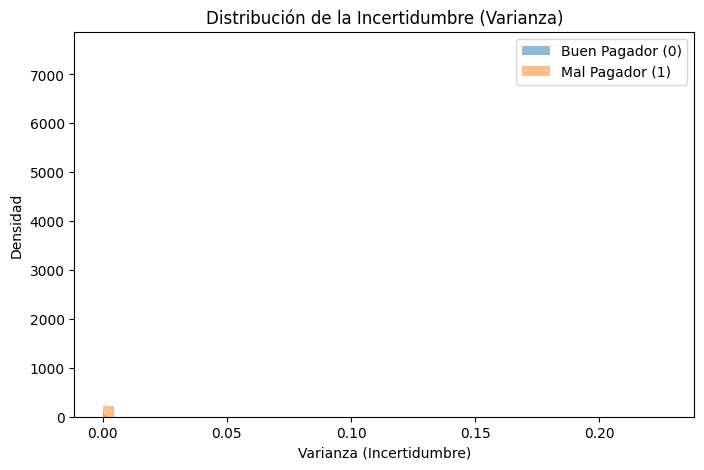

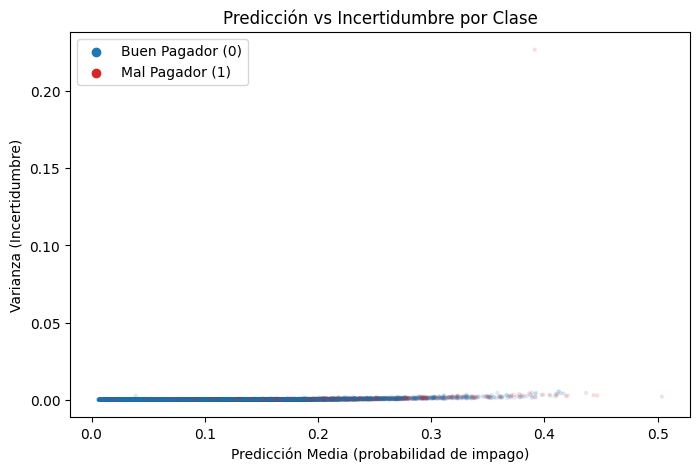


--- MÉTRICAS DE INCERTIDUMBRE ---
Varianza media (Buenos pagadores): 0.000102
Varianza media (Malos pagadores):  0.000291
Umbral de alta incertidumbre (percentil 90): 0.000174
Predicciones con alta incertidumbre: 3075 (10.0%)

¡Proceso completado con éxito!
¡Proceso completado con éxito!


In [22]:
# ==========================================
# 6. INCERTIDUMBRE (MC DROPOUT EN TEST)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

print("Calculando incertidumbre en el conjunto de Test...")

predicciones_multiples = []
for i in range(30): 
    preds = best_model(X_test, training=True) 
    predicciones_multiples.append(preds.numpy())

predicciones_multiples = np.array(predicciones_multiples).squeeze()

prediccion_media = np.mean(predicciones_multiples, axis=0)
incertidumbre_varianza = np.var(predicciones_multiples, axis=0)

# ==========================================
# 7. GRÁFICOS DE INCERTIDUMBRE
# ==========================================
varianza_buenos = incertidumbre_varianza[Y_test.flatten() == 0]
varianza_malos = incertidumbre_varianza[Y_test.flatten() == 1]

# Gráfico 1: Histograma (el que ya tenías)
plt.figure(figsize=(8, 5))
plt.hist(varianza_buenos, bins=50, alpha=0.5, label='Buen Pagador (0)', density=True)
plt.hist(varianza_malos, bins=50, alpha=0.5, label='Mal Pagador (1)', density=True)
plt.title('Distribución de la Incertidumbre (Varianza)')
plt.xlabel('Varianza (Incertidumbre)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Gráfico 2: Scatter predicción vs incertidumbre
plt.figure(figsize=(8, 5))
colores = ['tab:blue' if y == 0 else 'tab:red' for y in Y_test.flatten()]
plt.scatter(prediccion_media, incertidumbre_varianza, c=colores, alpha=0.1, s=5)
plt.xlabel('Predicción Media (probabilidad de impago)')
plt.ylabel('Varianza (Incertidumbre)')
plt.title('Predicción vs Incertidumbre por Clase')
# Leyenda manual
plt.scatter([], [], c='tab:blue', label='Buen Pagador (0)')
plt.scatter([], [], c='tab:red', label='Mal Pagador (1)')
plt.legend()
plt.show()

# Métricas resumen
print("\n--- MÉTRICAS DE INCERTIDUMBRE ---")
print(f"Varianza media (Buenos pagadores): {np.mean(varianza_buenos):.6f}")
print(f"Varianza media (Malos pagadores):  {np.mean(varianza_malos):.6f}")
umbral_alta = np.percentile(incertidumbre_varianza, 90)
n_alta = np.sum(incertidumbre_varianza > umbral_alta)
print(f"Umbral de alta incertidumbre (percentil 90): {umbral_alta:.6f}")
print(f"Predicciones con alta incertidumbre: {n_alta} ({100*n_alta/len(incertidumbre_varianza):.1f}%)")

print("\n¡Proceso completado con éxito!")
print("¡Proceso completado con éxito!")